# QC further exploration

# Fraction of reads in genes
As a QC step, I am calculating the fraction of reads in gene bodies. </br>
Normally we would look at TSS enrichement for QC, but the rabbit genome is badly annotated, which could explain low TSS enrichment.</br>
Fraction of Reads in Peaks (FRIP) is another method. Our doesn't look as good as expected.</br>
Here, I am to take a similar approach, but look at Fraction of Read in Genes, and compare this to another scATAC-seq dataset. </br>
</br>
I will do this by using ArchR's addFeatureMatrix, where the input bed file will contain all gene bodies. This will automatically add FRIP to the metadata.

In [1]:
here::i_am("01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))
library(viridis)
library(stringr)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/code

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==

In [4]:
# I/O
io$outdir =  file.path(io$output.directory,"QualityControl")

addArchRThreads(8)
options(repr.plot.width=15, repr.plot.height=10)

Setting default number of Parallel threads to 8.



Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


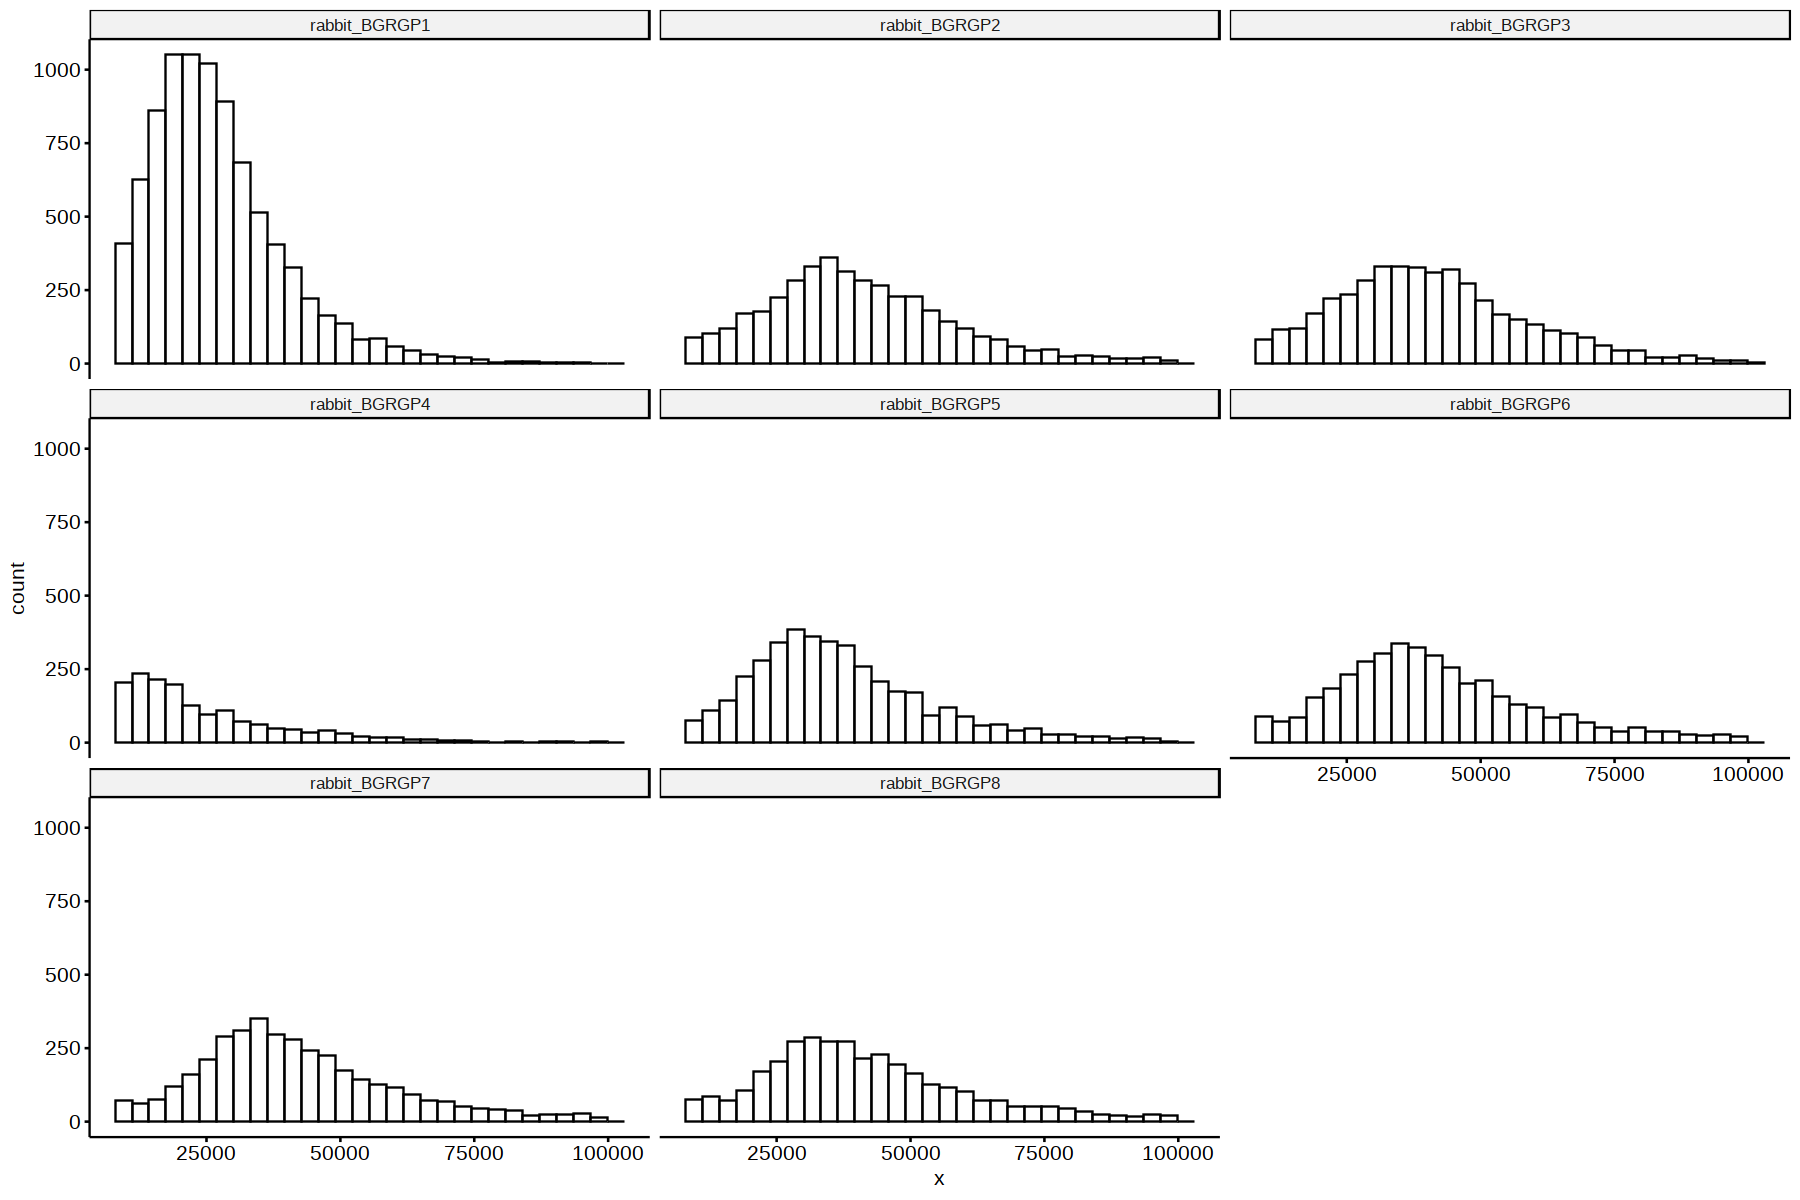

In [4]:
gghistogram(ArchRProject@cellColData$nFrags) + facet_wrap(~ArchRProject@cellColData$sample)

# Try to calculate FRIP for genes instead of peaks
I think archR only returns FRIP when running addPeakMatrix </br>
although it is also ran when adding addFeatureMatrix, the FRIP isn't returned when running on a archrproject</br>
possibly it is returned when running on an arrow file, let's test: </br>

In [47]:
ArchRProject@sampleColData$ArrowFiles[1]

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/ArchR/Project/ArrowFiles/rabbit_BGRGP1.arrow"

In [93]:
calculate_FRIP = function(Arrow, name){
    tmp = addFeatureMatrix(Arrow, 
                 features = ArchRProject@geneAnnotation$genes,
                 matrixName = "Genes")
    
    tmp2 = as.data.table(tmp, keep.rownames=T) %>% 
         setnames('rn', 'input') %>%
        .[input!='ArrowFile'] %>% 
         .[,`:=`(stat=str_split(input, '\\.') %>% map_chr(1),
                cell=str_split(input, '\\.') %>% map_chr(2))] %>%
        .[stat=='FRIP'] %>%
        .[,c('cell', 'tmp')] %>% setnames('tmp', paste0('FRIP_', name))
    
    return(tmp2)
}

In [94]:
test = calculate_FRIP(ArchRProject@sampleColData$ArrowFiles[4], 'Gene')

In [95]:
head(test)

cell,FRIP_Gene
<chr>,<chr>
rabbit_BGRGP4#TGACAACAGACCCTAT-1,0.466859428364179
rabbit_BGRGP4#CCAGAATCAAGCACTT-1,0.477114851044008
rabbit_BGRGP4#GGAACCCAGTCAGGAC-1,0.513899637489308
rabbit_BGRGP4#ATTGTGGGTGAATGGC-1,0.490738283801437
rabbit_BGRGP4#ACCATCCCACACATGT-1,0.51169127269753
rabbit_BGRGP4#CTCCCAAGTCAAACAA-1,0.454840459836007


In [110]:
FRIP_genes = lapply(ArchRProject@sampleColData$ArrowFiles, calculate_FRIP, name='Gene') %>%
    rbindlist() %>% .[,FRIP_Gene:=as.numeric(FRIP_Gene)]

In [111]:
fwrite(FRIP_genes, sprintf('%s/genes_FRIP.txt.gz', io$outdir))

In [3]:
FRIP_genes = fread(sprintf('%s/genes_FRIP.txt.gz', io$outdir))

In [31]:
round(median(FRIP_genes$FRIP_Gene),2)

[1] 0.4792578

In [15]:
meta = as.data.table(ArchRProject@cellColData)

In [28]:
test = FRIP_genes[,sample:=str_split(cell, '#') %>% map_chr(1)] %>% 
    .[,FRIP_Gene:=as.numeric(FRIP_Gene)] %>%
    merge(., meta[,c('sample', 'stage')] %>% unique(by='sample'), by='sample') %>%
    .[,sample:=gsub('rabbit_', '', sample)]

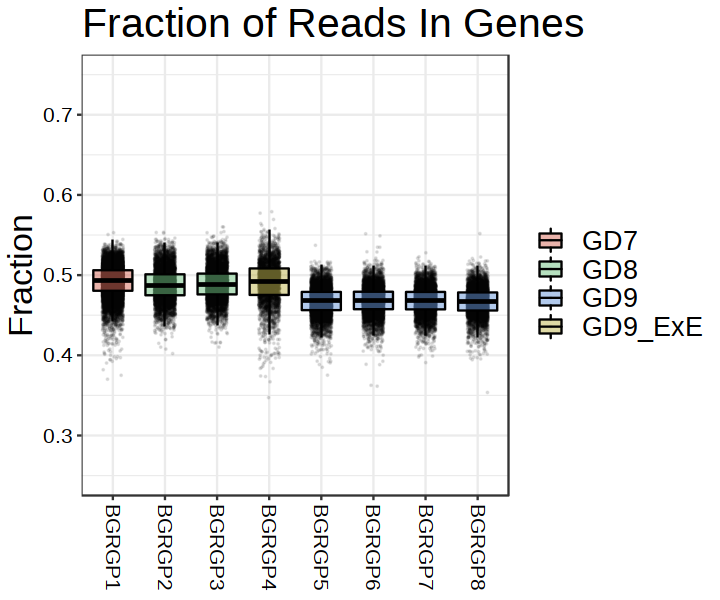

In [35]:
options(repr.plot.width=6, repr.plot.height=5)
p = ggplot(test, aes(sample, FRIP_Gene, fill=stage)) + 
  #  geom_violin() + 
    geom_point(size=0.05, alpha=0.1, position=position_jitter(width = 0.2)) + 
    geom_boxplot(outlier.shape=NA, alpha=0.5, col='black') +
    scale_fill_manual(values=opts$stage.colors) + 
    ylim(0.25, 0.75) +
    ggtitle('Fraction of Reads In Genes') + 
    ylab('Fraction') + 
    theme_bw() +
    theme(
            legend.position = "right",
            legend.title = element_blank(),
            axis.text.x = element_text(colour="black",size=rel(0.75), angle=-90, hjust=0, vjust=0.5),  
            axis.text.y = element_text(colour="black",size=rel(0.75)),  
            axis.title.x = element_blank(),
            text=element_text(size=20, colour='black'),
            strip.background=element_blank()
        ) 
p

In [37]:
pdf(sprintf('%s/FRIG.pdf', io$outdir), width=6, height=3)
    p
dev.off()

png 
  2

In [32]:
head(FRIP_genes)
head(test)

cell,FRIP_Gene,sample
<chr>,<dbl>,<chr>
rabbit_BGRGP1#AATGTCGAGTTCAGGG-1,0.5026222,rabbit_BGRGP1
rabbit_BGRGP1#TAGCACACACTCGCAG-1,0.4909617,rabbit_BGRGP1
rabbit_BGRGP1#GAAGAGCGTATCTCAG-1,0.4965860,rabbit_BGRGP1
rabbit_BGRGP1#ACGTTAGGTTCCCGGA-1,0.5027789,rabbit_BGRGP1
rabbit_BGRGP1#TGTACGAGTAACTCCA-1,0.4870879,rabbit_BGRGP1
rabbit_BGRGP1#GATGGCCCAAGCACTT-1,0.4985834,rabbit_BGRGP1


sample,cell,FRIP_Gene,stage
<chr>,<chr>,<dbl>,<chr>
BGRGP1,rabbit_BGRGP1#AATGTCGAGTTCAGGG-1,0.5026222,GD7
BGRGP1,rabbit_BGRGP1#TAGCACACACTCGCAG-1,0.4909617,GD7
BGRGP1,rabbit_BGRGP1#GAAGAGCGTATCTCAG-1,0.4965860,GD7
BGRGP1,rabbit_BGRGP1#ACGTTAGGTTCCCGGA-1,0.5027789,GD7
BGRGP1,rabbit_BGRGP1#TGTACGAGTAACTCCA-1,0.4870879,GD7
BGRGP1,rabbit_BGRGP1#GATGGCCCAAGCACTT-1,0.4985834,GD7


# Try to calculate TSS score for centre of peaks in promoter regions


In [22]:
# Get peakset
peakset = as.data.table(ArchRProject@peakSet) %>%
    .[peakType=='Promoter'] %>% # subset to promoters
    .[,centre:=(start+end)/2] %>% # add peak centre
    .[,tx_id:=.I] %>% # add id
    .[, tx_name:=paste0(nearestGene, '_', tx_id)] # add name

# filter by peaks closest to annotated TSS if multiple peaks (test with an without)
peakset = peakset[order(distToTSS)][distToTSS<=500] %>% unique(by='nearestGene')

## Add strand
# Strand info from TSS gives weird results because the closest TSS is not necessarily the TSS of the nearest gene, so trying with nearest gene strand instead
#TSS_info = as.data.table(getTSS(ArchRProject))[,c('tx_name', 'strand')] %>% setnames('tx_name', 'nearestTSS')
#peakset = merge(peakset[,-'strand'], TSS_info, by='nearestTSS')

strand_info = as.data.table(ArchRProject@geneAnnotation$genes)[,c('symbol', 'strand')] %>% setnames('symbol', 'nearestGene') %>% unique(by='nearestGene')
peakset = merge(peakset[,-'strand'], strand_info, by='nearestGene')

# make granges object
peakset.gr = GRanges(
    seqnames = Rle(peakset$seqnames),
    ranges = IRanges(peakset$centre),
    strand = Rle(strand(peakset$strand)),
    GC = peakset$GC,
    tx_id = peakset$tx_id,
    tx_name = peakset$tx_name)

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


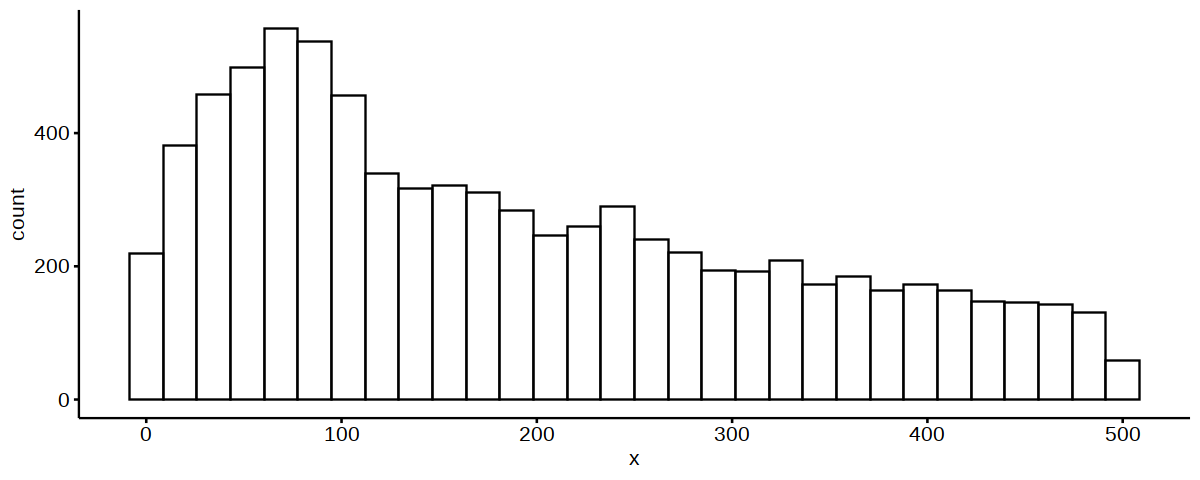

In [195]:
options(repr.plot.width=10, repr.plot.height=4)
gghistogram(peakset$distToTSS)

In [204]:
peakset.gr

GRanges object with 8015 ranges and 3 metadata columns:
         seqnames    ranges strand |        GC     tx_id            tx_name
            <Rle> <IRanges>  <Rle> | <numeric> <integer>        <character>
     [1]     chr9  43419054      - |    0.6986     10277      5S_rRNA_10277
     [2]     chr8  34619410      + |    0.4092      9216           A2M_9216
     [3]    chr14  31801372      - |    0.5808     15739        A4GNT_15739
     [4]     chr4  37145098      - |    0.5968      5767          AAAS_5767
     [5]     chr2  48150155      - |    0.6747      2501         AADAT_2501
     ...      ...       ...    ... .       ...       ...                ...
  [8011]     chrX  34243585      + |    0.5170     22468 ocu-mir-502a_22468
  [8012]     chrX 108855531      - |    0.6168     22852  ocu-mir-503_22852
  [8013]    chr11  75636092      - |    0.4830     11626  ocu-mir-582_11626
  [8014]     chrX  34241599      + |    0.4930     22467  ocu-mir-660_22467
  [8015]     chr3  19951830     

In [208]:
getTSS(ArchRProject)

GRanges object with 38003 ranges and 2 metadata columns:
                     seqnames    ranges strand |     tx_id            tx_name
                        <Rle> <IRanges>  <Rle> | <integer>        <character>
  ENSOCUG00000014251     chr1     15188      + |         1 ENSOCUT00000014253
  ENSOCUG00000014251     chr1     20324      + |         2 ENSOCUT00000038745
  ENSOCUG00000005054     chr1     52453      + |         3 ENSOCUT00000005053
  ENSOCUG00000005044     chr1     75200      + |         4 ENSOCUT00000005041
  ENSOCUG00000005028     chr1    125890      + |         5 ENSOCUT00000005032
                 ...      ...       ...    ... .       ...                ...
  ENSOCUG00000000255     chrX 111369675      - |     37999 ENSOCUT00000000255
  ENSOCUG00000007220     chrX 111496239      - |     38000 ENSOCUT00000007220
  ENSOCUG00000019315     chrX 111494835      - |     38001 ENSOCUT00000019315
  ENSOCUG00000022547     chrX 111532815      - |     38002 ENSOCUT00000023399
  ENSOC

In [202]:
seqlengths(getTSS(ArchRProject))

chr1      chr2      chr3      chr4      chr5      chr6      chr7      chr8 
194850757 174332312 155691105  91394100  37992211  27502587 173684459 111795807 
     chr9     chr10     chr11     chr12     chr13     chr14     chr15     chr16 
116251907  47997241  87554214 155355395 143360832 163896628 109054052  84478945 
    chr17     chr18     chr19     chr20     chr21      chrX 
 85008467  69800736  57279966  33191332  15578276 111700775

In [152]:
addArchRThreads(threads = 16)

TSS_scores = plotTSSEnrichment(ArchRProj = ArchRProject,
                 TSS = peakset.gr,
                 returnDF = TRUE)

Setting default number of Parallel threads to 16.



In [205]:
TSS_scores = as.data.table(TSS_scores)

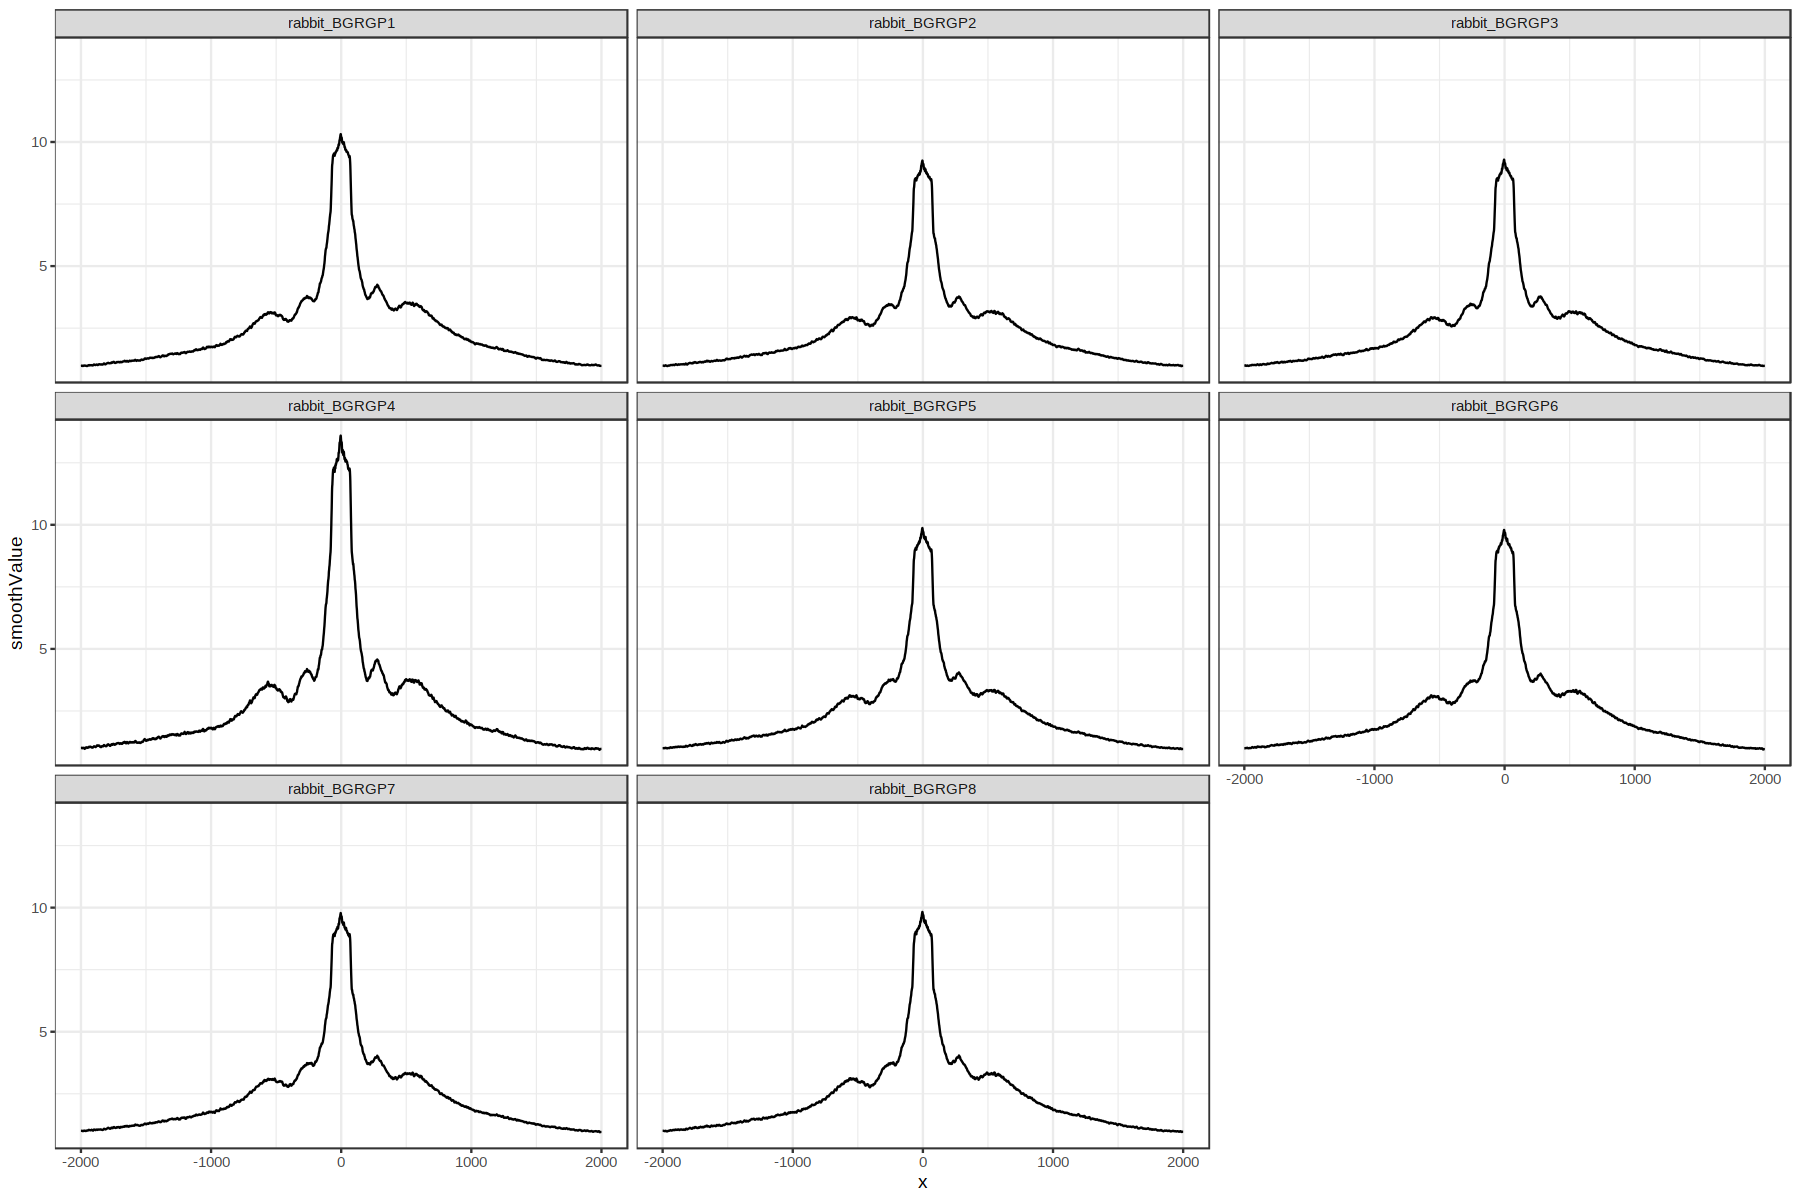

In [206]:
options(repr.plot.width=15, repr.plot.height=10)
ggplot(TSS_scores, aes(x, smoothValue)) + geom_line() + facet_wrap(~group) + theme_bw()

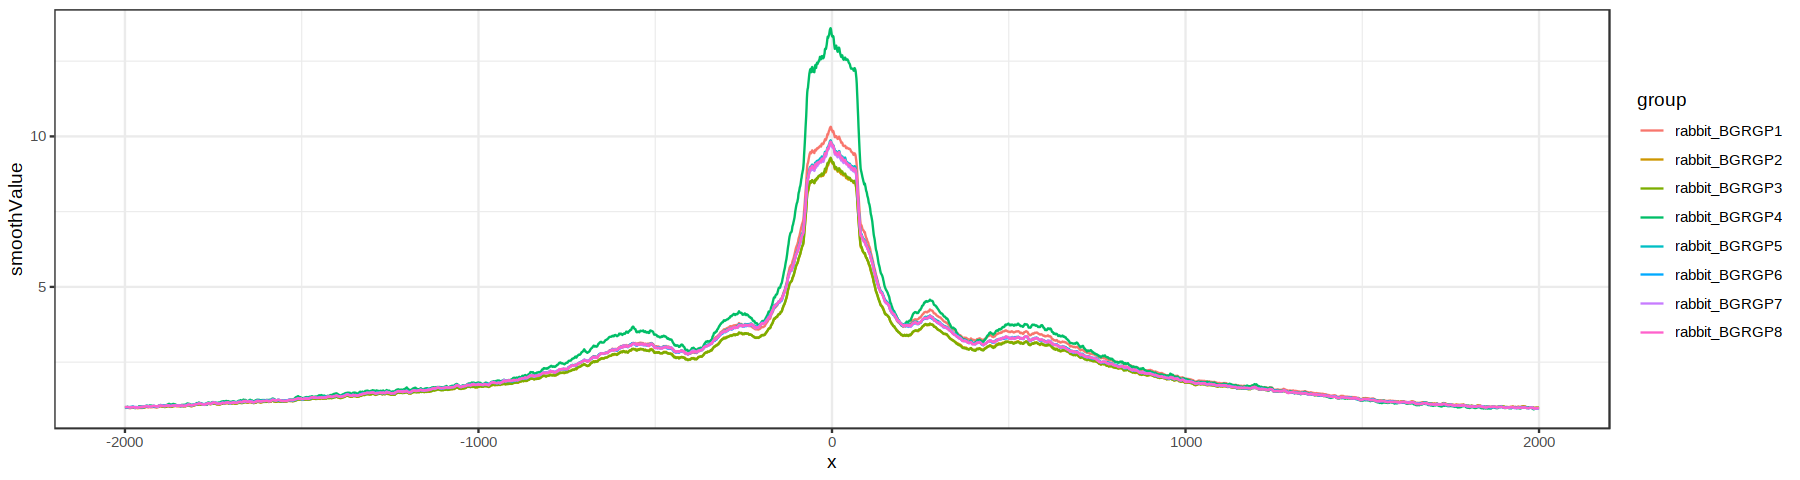

In [207]:
options(repr.plot.width=15, repr.plot.height=4)
ggplot(TSS_scores, aes(x, smoothValue, col=group)) + geom_line() + theme_bw()

In [155]:
# Determine TSS enrichment with those peaks at per cell level

In [175]:
TSS_per_cell = mclapply(ArchRProject@sampleColData$ArrowFiles, function(Arrow){
    tmp = ArchR:::.fastTSSEnrichment(
                 TSS=peakset.gr,
                ArrowFile = Arrow)
    tmp = as.data.table(tmp$tssScores, keep.rownames=T) %>% setnames(c('cell', 'TSSscore'))
}, mc.cores=16) %>% rbindlist()

In [180]:
meta = as.data.table(ArchRProject@cellColData) %>% 
    merge(.,TSS_per_cell, by='cell')

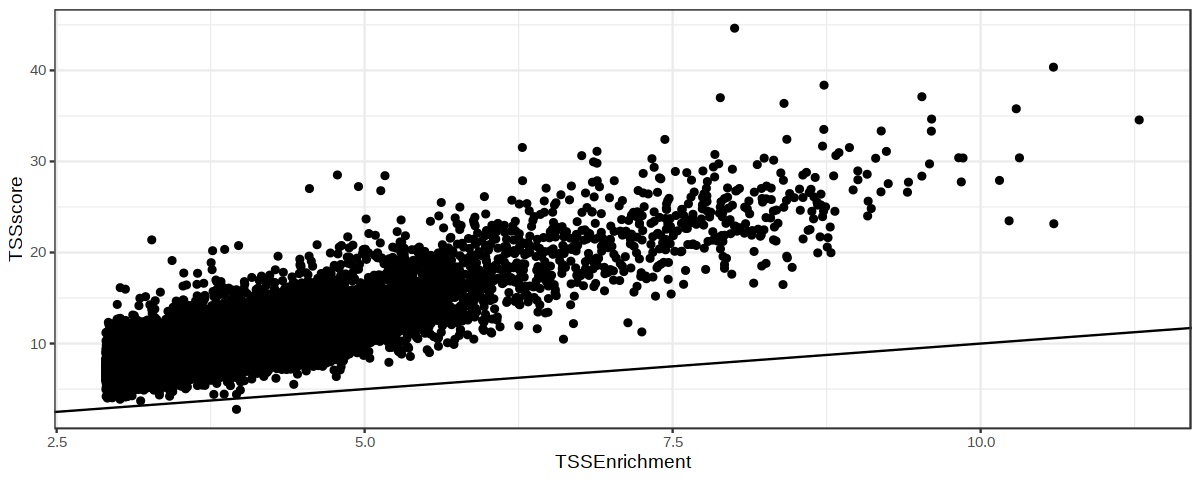

In [198]:
options(repr.plot.width=10, repr.plot.height=4)
ggplot(meta, aes(TSSEnrichment, TSSscore)) + geom_point() + geom_abline(slope=1) + theme_bw()

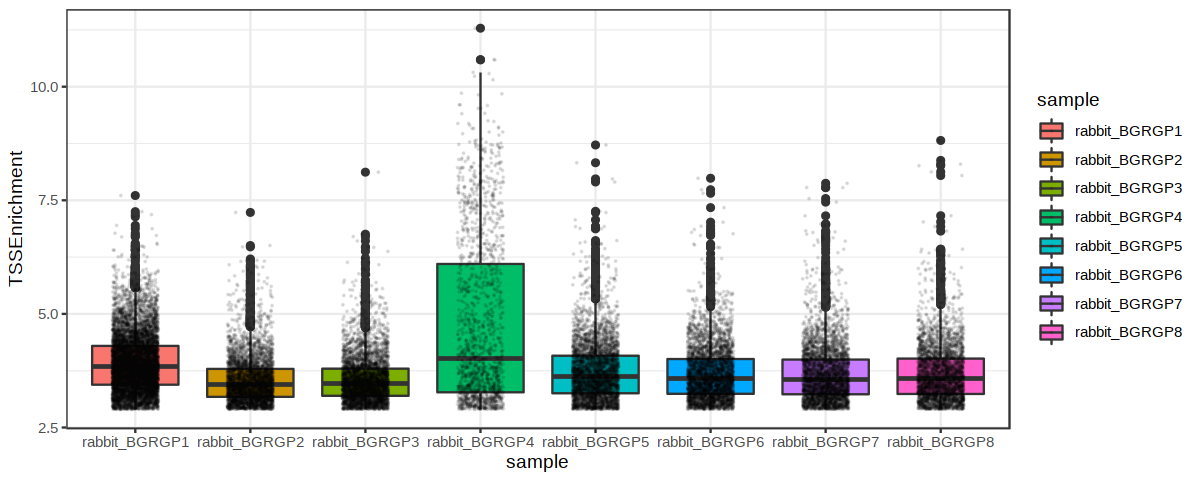

In [199]:
ggplot(meta, aes(sample, TSSEnrichment, fill=sample)) + geom_boxplot(alpha=1) + geom_point(position=position_jitter(width=0.2), size=0.05, alpha=0.1)  + theme_bw()

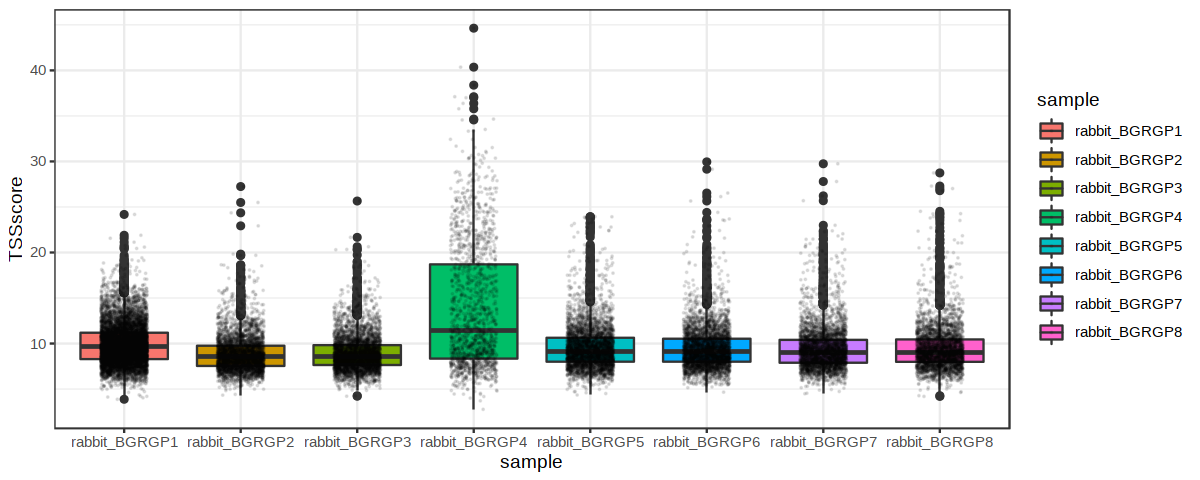

In [200]:
ggplot(meta, aes(sample, TSSscore, fill=sample)) + geom_boxplot(alpha=1) + geom_point(position=position_jitter(width=0.2), size=0.05, alpha=0.1)  + theme_bw()

# TSS enrichment where TSS is start of the first exon.
In case this is not always true in the TSS annotation

In [41]:
# Get peakset
peakset = as.data.table(ArchRProject@geneAnnotation$genes)

# make granges object
peakset.gr = GRanges(seqnames = Rle(peakset$seqnames),
   ranges = IRanges(as.character(peakset$start)),
   strand = Rle(strand(peakset$strand)),
   tx_id = peakset$gene_id,
   tx_name = peakset$symbol)

In [43]:
addArchRThreads(threads = 16)

TSS_scores = plotTSSEnrichment(ArchRProj = ArchRProject,
                 TSS = peakset.gr,
                 returnDF = TRUE)

Setting default number of Parallel threads to 16.



In [44]:
TSS_scores = as.data.table(TSS_scores)

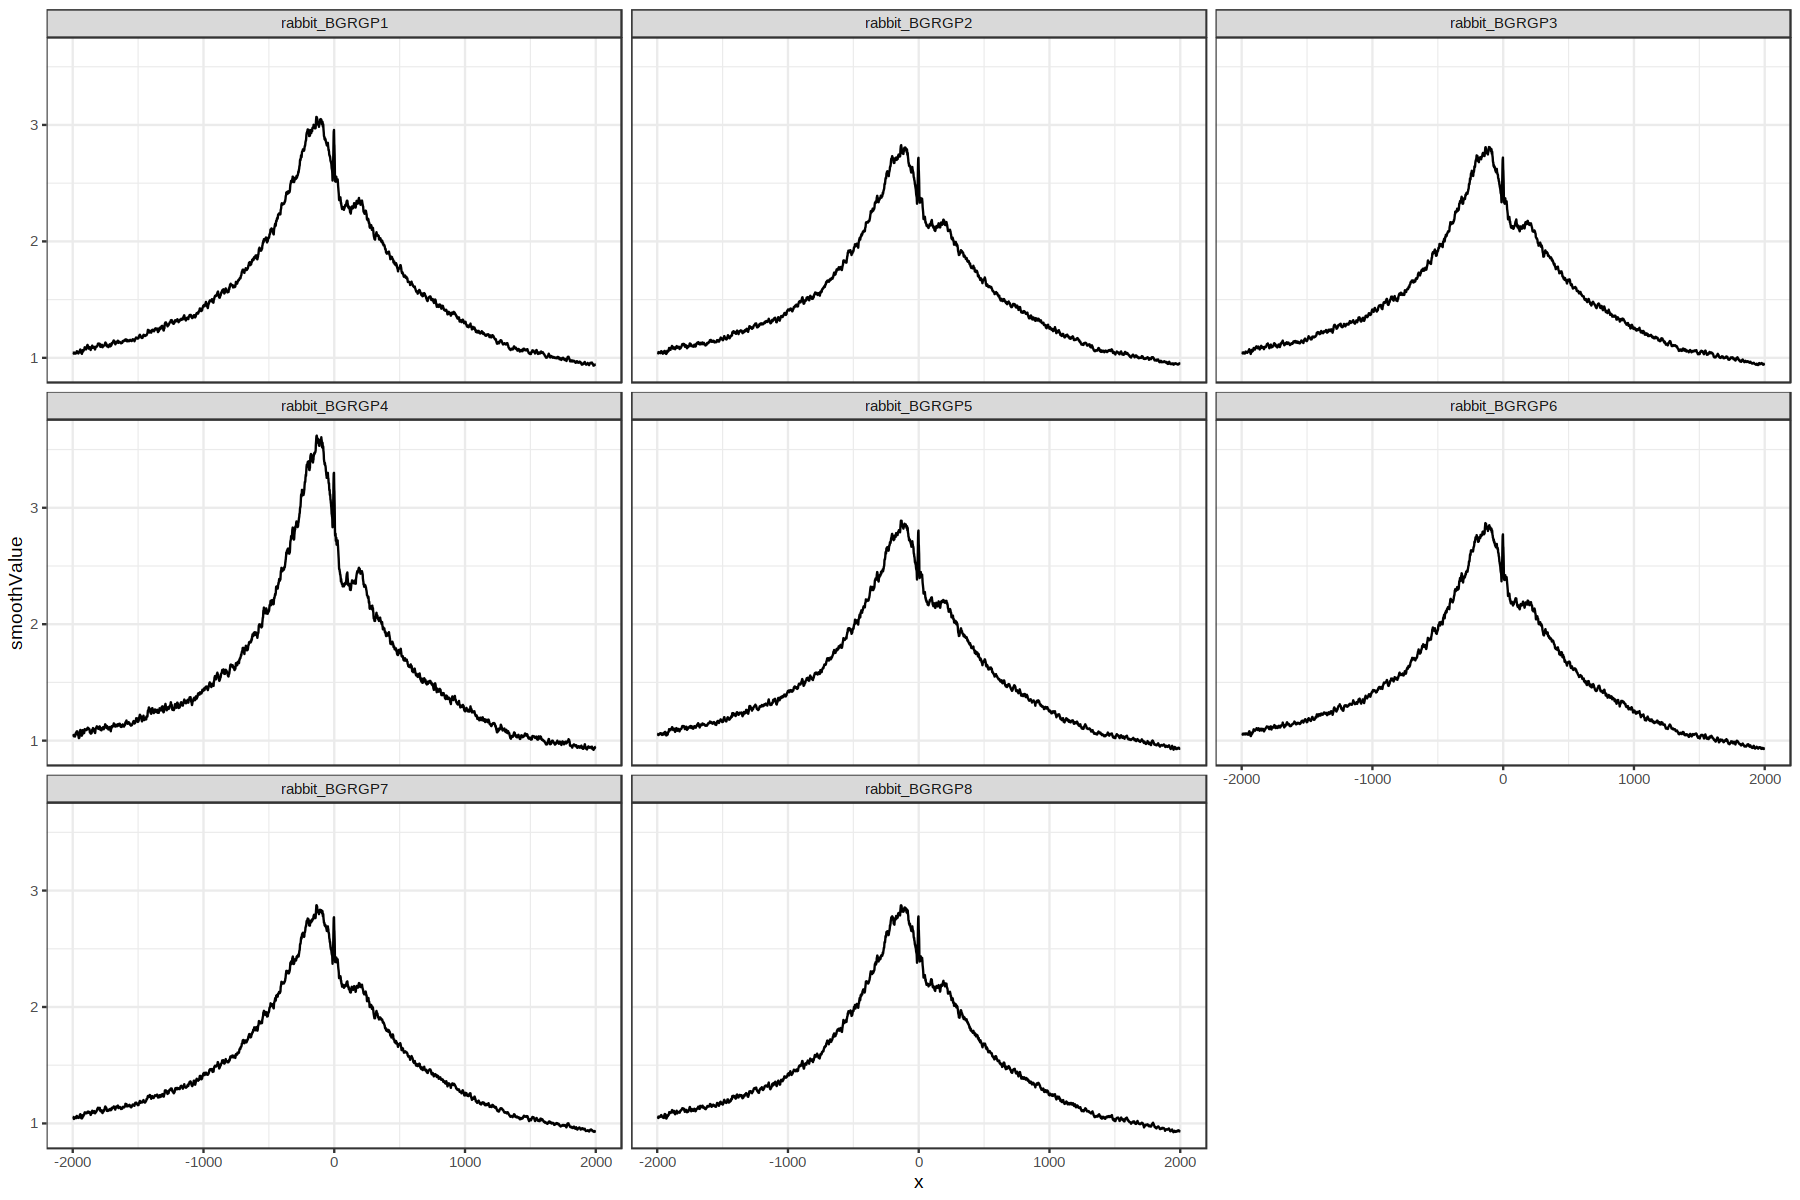

In [45]:
options(repr.plot.width=15, repr.plot.height=10)
ggplot(TSS_scores, aes(x, smoothValue)) + geom_line() + facet_wrap(~group) + theme_bw()

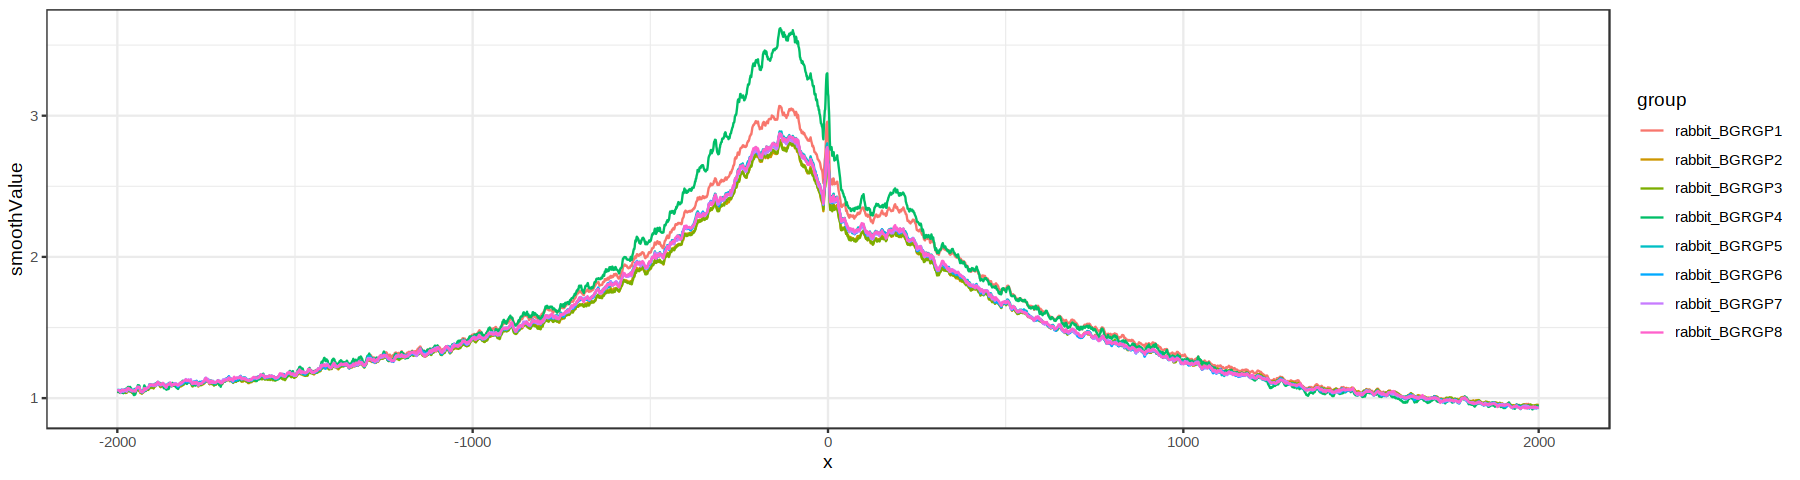

In [46]:
options(repr.plot.width=15, repr.plot.height=4)
ggplot(TSS_scores, aes(x, smoothValue, col=group)) + geom_line() + theme_bw()

### TSS from new GTF file
They haven't annotated which chr the genes are on and also not what the gene names are so may not be super useful

In [57]:
gtf = fread("/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/genome/new_gtf/genomic.gtf")

Warning message in fread("/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/genome/new_gtf/genomic.gtf"):
“Detected 1 column names but the data has 9 columns (i.e. invalid file). Added 8 extra default column names at the end.”
Warning message in fread("/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/genome/new_gtf/genomic.gtf"):
“Discarded single-line footer: <<###>>”


In [55]:
gtf = gtf[V3=='gene']

In [ ]:
# make granges object
peakset.gr = GRanges(seqnames = Rle(peakset$seqnames),
   ranges = IRanges(as.character(peakset$start)),
   strand = Rle(strand(peakset$strand)),
   tx_id = peakset$gene_id,
   tx_name = peakset$symbol)

In [59]:
tail(gtf)

#!annotation-source NCBI RefSeq Oryctolagus cuniculus Annotation Release 103,V2,V3,V4,V5,V6,V7,V8,V9
<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
NC_001913.1,RefSeq,gene,15314,15379,.,+,.,"gene_id ""KEF51_t21""; transcript_id """"; db_xref ""GeneID:64985231""; gbkey ""Gene""; gene_biotype ""tRNA""; locus_tag ""KEF51_t21"";"
NC_001913.1,RefSeq,transcript,15314,15379,.,+,.,"gene_id ""KEF51_t21""; transcript_id ""unassigned_transcript_1221""; gbkey ""tRNA""; locus_tag ""KEF51_t21""; product ""tRNA-Thr""; transcript_biotype ""tRNA"";"
NC_001913.1,RefSeq,exon,15314,15379,.,+,.,"gene_id ""KEF51_t21""; transcript_id ""unassigned_transcript_1221""; locus_tag ""KEF51_t21""; product ""tRNA-Thr""; transcript_biotype ""tRNA""; exon_number ""1"";"
NC_001913.1,RefSeq,gene,15380,15445,.,-,.,"gene_id ""KEF51_t22""; transcript_id """"; db_xref ""GeneID:64985245""; gbkey ""Gene""; gene_biotype ""tRNA""; locus_tag ""KEF51_t22"";"
NC_001913.1,RefSeq,transcript,15380,15445,.,-,.,"gene_id ""KEF51_t22""; transcript_id ""unassigned_transcript_1222""; gbkey ""tRNA""; locus_tag ""KEF51_t22""; product ""tRNA-Pro""; transcript_biotype ""tRNA"";"
NC_001913.1,RefSeq,exon,15380,15445,.,-,.,"gene_id ""KEF51_t22""; transcript_id ""unassigned_transcript_1222""; locus_tag ""KEF51_t22""; product ""tRNA-Pro""; transcript_biotype ""tRNA""; exon_number ""1"";"


In [65]:
ArchRProject@geneAnnotation$genes

GRanges object with 21102 ranges and 2 metadata columns:
          seqnames              ranges strand |            gene_id
             <Rle>           <IRanges>  <Rle> |        <character>
      [1]     chr1         15188-30378      + | ENSOCUG00000014251
      [2]     chr1         52453-53037      + | ENSOCUG00000005054
      [3]     chr1         57421-74905      - | ENSOCUG00000005046
      [4]     chr1         75200-85748      + | ENSOCUG00000005044
      [5]     chr1         92423-95845      - | ENSOCUG00000005040
      ...      ...                 ...    ... .                ...
  [21098]     chrX 111491397-111496239      - | ENSOCUG00000007220
  [21099]     chrX 111494764-111494835      - | ENSOCUG00000019315
  [21100]     chrX 111523844-111597291      + | ENSOCUG00000029751
  [21101]     chrX 111532709-111532815      - | ENSOCUG00000022547
  [21102]     chrX 111628200-111629717      - | ENSOCUG00000027130
                      symbol
                 <character>
      [1]     

In [66]:
ArchRProject@geneAnnotation$TSS

GRanges object with 38003 ranges and 2 metadata columns:
                     seqnames    ranges strand |     tx_id            tx_name
                        <Rle> <IRanges>  <Rle> | <integer>        <character>
  ENSOCUG00000014251     chr1     15188      + |         1 ENSOCUT00000014253
  ENSOCUG00000014251     chr1     20324      + |         2 ENSOCUT00000038745
  ENSOCUG00000005054     chr1     52453      + |         3 ENSOCUT00000005053
  ENSOCUG00000005044     chr1     75200      + |         4 ENSOCUT00000005041
  ENSOCUG00000005028     chr1    125890      + |         5 ENSOCUT00000005032
                 ...      ...       ...    ... .       ...                ...
  ENSOCUG00000000255     chrX 111369675      - |     37999 ENSOCUT00000000255
  ENSOCUG00000007220     chrX 111496239      - |     38000 ENSOCUT00000007220
  ENSOCUG00000019315     chrX 111494835      - |     38001 ENSOCUT00000019315
  ENSOCUG00000022547     chrX 111532815      - |     38002 ENSOCUT00000023399
  ENSOC

# Global peak enrichment

In [14]:
# Get peakset
peakset = as.data.table(ArchRProject@peakSet) %>%
   # .[peakType=='Promoter'] %>% # subset to promoters # skipped bc using all peaks
    .[,centre:=(start+end)/2] %>% # add peak centre
    .[,tx_id:=.I] %>% # add id
    .[, tx_name:=paste0(nearestGene, '_', tx_id)] # add name

# filter by peaks closest to annotated TSS if multiple peaks (test with an without)
#peakset = peakset[order(distToTSS)][distToTSS<=500] %>% unique(by='nearestGene')

## Add strand
# Strand info from TSS gives weird results because the closest TSS is not necessarily the TSS of the nearest gene, so trying with nearest gene strand instead
#TSS_info = as.data.table(getTSS(ArchRProject))[,c('tx_name', 'strand')] %>% setnames('tx_name', 'nearestTSS')
#peakset = merge(peakset[,-'strand'], TSS_info, by='nearestTSS')

#strand_info = as.data.table(ArchRProject@geneAnnotation$genes)[,c('symbol', 'strand')] %>% setnames('symbol', 'nearestGene') %>% unique(by='nearestGene')
#peakset = merge(peakset[,-'strand'], strand_info, by='nearestGene')

# make granges object
peakset.gr = GRanges(
    seqnames = Rle(peakset$seqnames),
    ranges = IRanges(peakset$centre),
    strand = Rle(strand(peakset$strand)),
    GC = peakset$GC,
    tx_id = peakset$tx_id,
    tx_name = peakset$tx_name)

In [ ]:
# Set threshold for Peak quality

In [15]:
peakset.gr

GRanges object with 332773 ranges and 3 metadata columns:
           seqnames    ranges strand |        GC     tx_id       tx_name
              <Rle> <IRanges>  <Rle> | <numeric> <integer>   <character>
       [1]     chr1       381      * |    0.5649         1       WDR31_1
       [2]     chr1      1245      * |    0.5649         2       WDR31_2
       [3]     chr1      1960      * |    0.5848         3       WDR31_3
       [4]     chr1      2928      * |    0.7106         4       WDR31_4
       [5]     chr1      3526      * |    0.4810         5       WDR31_5
       ...      ...       ...    ... .       ...       ...           ...
  [332769]     chrX 111629606      * |    0.5968    332769 GPR101_332769
  [332770]     chrX 111630375      * |    0.5549    332770 GPR101_332770
  [332771]     chrX 111631707      * |    0.6048    332771 GPR101_332771
  [332772]     chrX 111667352      * |    0.5848    332772 GPR101_332772
  [332773]     chrX 111679109      * |    0.4411    332773 GPR101_

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


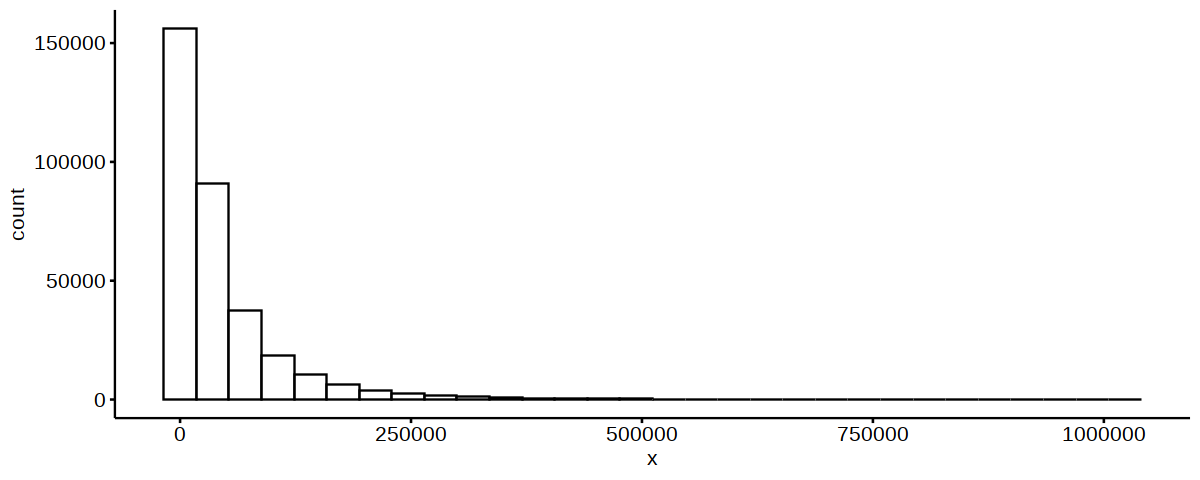

In [4]:
options(repr.plot.width=10, repr.plot.height=4)
gghistogram(peakset$distToTSS)

In [10]:
addArchRThreads(threads = 16)

TSS_scores = plotTSSEnrichment(ArchRProj = ArchRProject,
                 TSS = peakset.gr,
                 returnDF = TRUE)

Setting default number of Parallel threads to 16.



In [11]:
TSS_scores = as.data.table(TSS_scores)

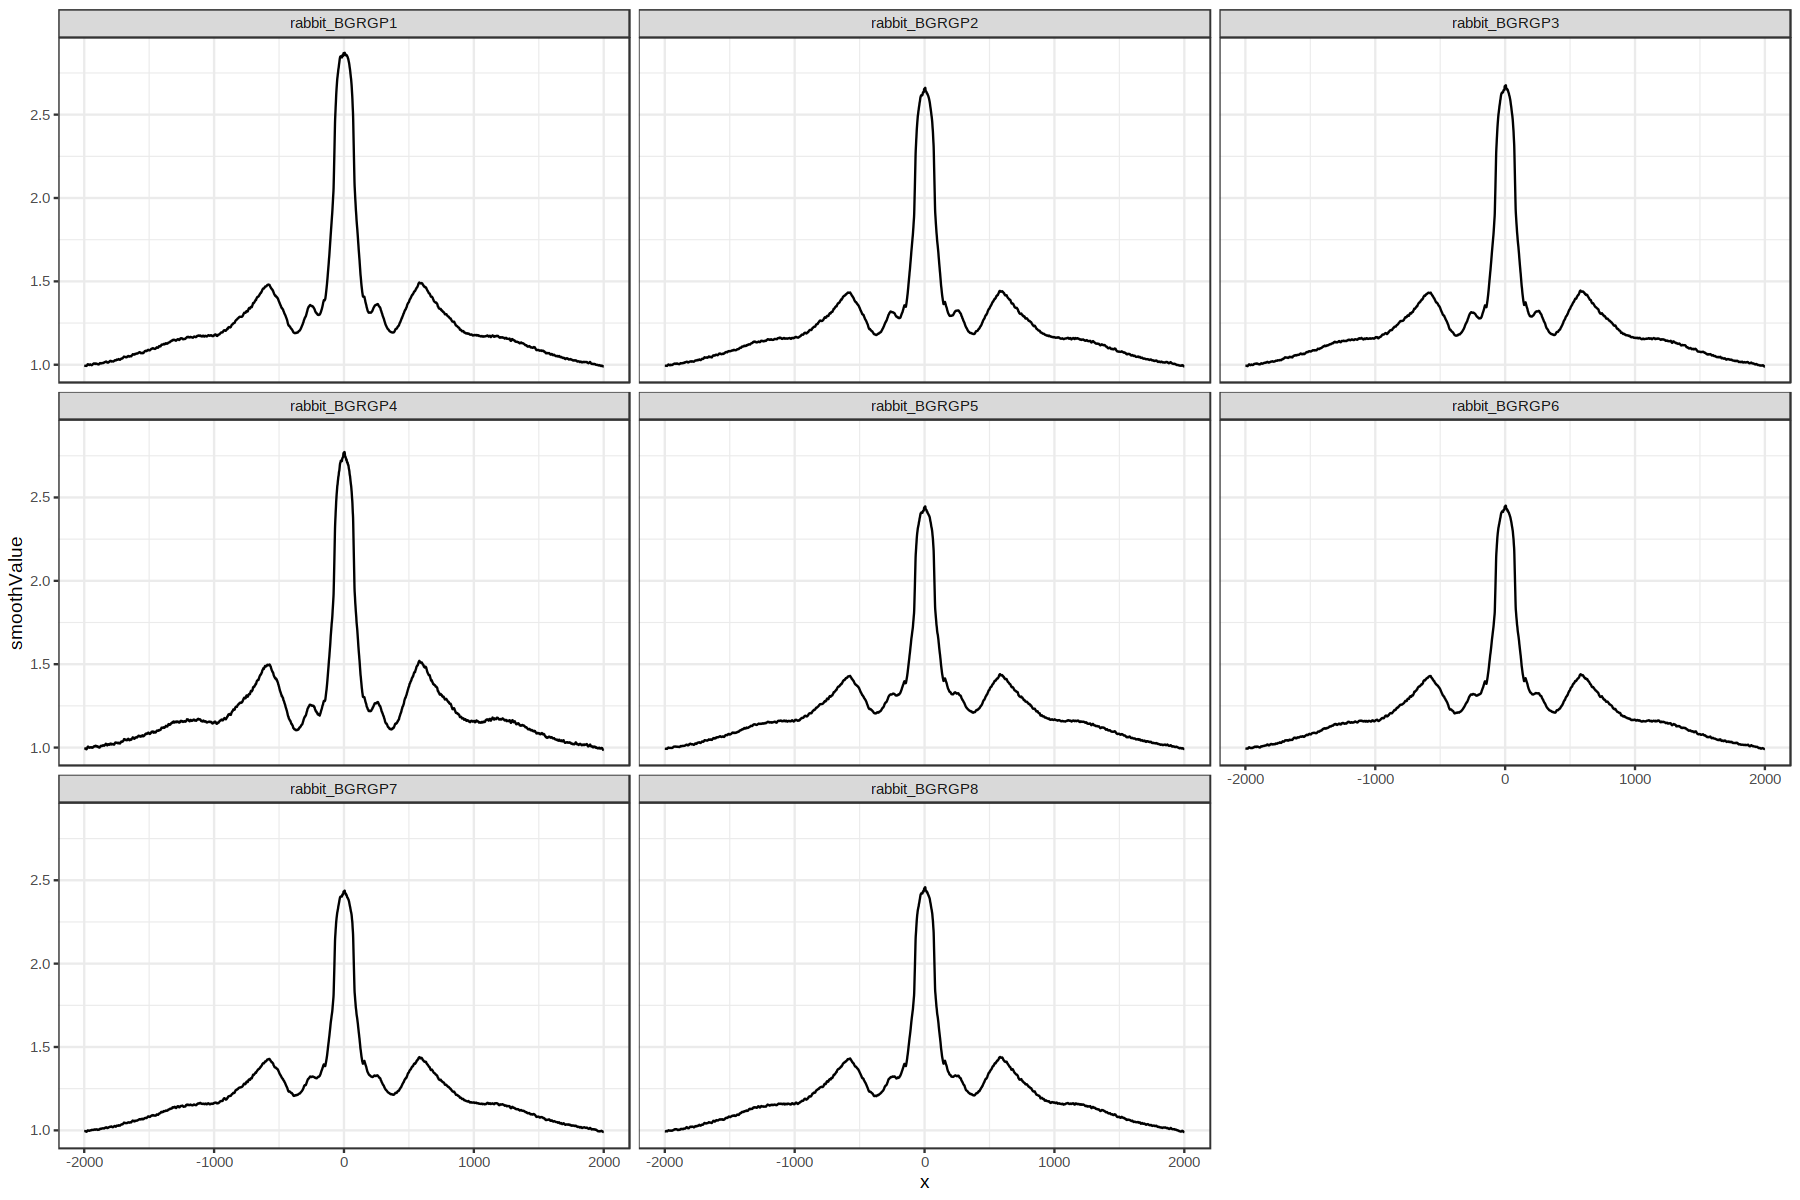

In [12]:
options(repr.plot.width=15, repr.plot.height=10)
ggplot(TSS_scores, aes(x, smoothValue)) + geom_line() + facet_wrap(~group) + theme_bw()

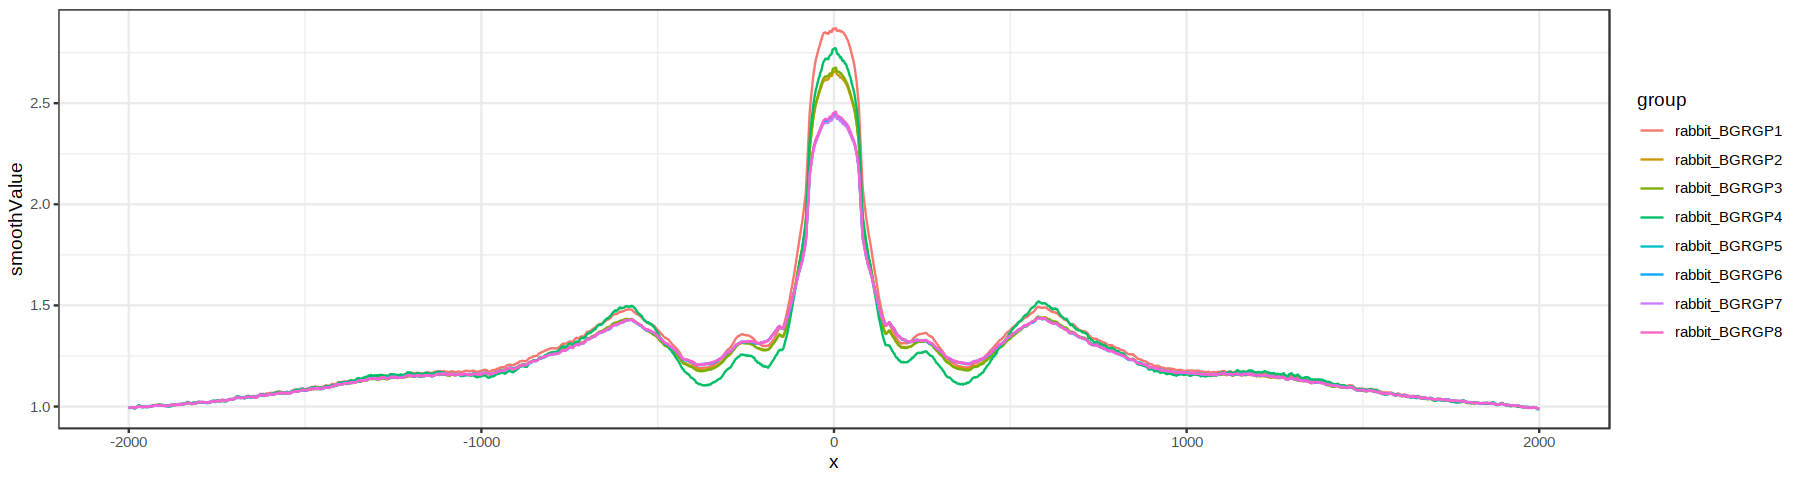

In [13]:
options(repr.plot.width=15, repr.plot.height=4)
ggplot(TSS_scores, aes(x, smoothValue, col=group)) + geom_line() + theme_bw()

In [ ]:
# Determine TSS enrichment with those peaks at per cell level

In [5]:
TSS_per_cell = mclapply(ArchRProject@sampleColData$ArrowFiles, function(Arrow){
    tmp = ArchR:::.fastTSSEnrichment(
                 TSS=peakset.gr,
                ArrowFile = Arrow)
    tmp = as.data.table(tmp$tssScores, keep.rownames=T) %>% setnames(c('cell', 'TSSscore'))
}, mc.cores=16) %>% rbindlist()

In [6]:
meta = as.data.table(ArchRProject@cellColData) %>% 
    merge(.,TSS_per_cell, by='cell')

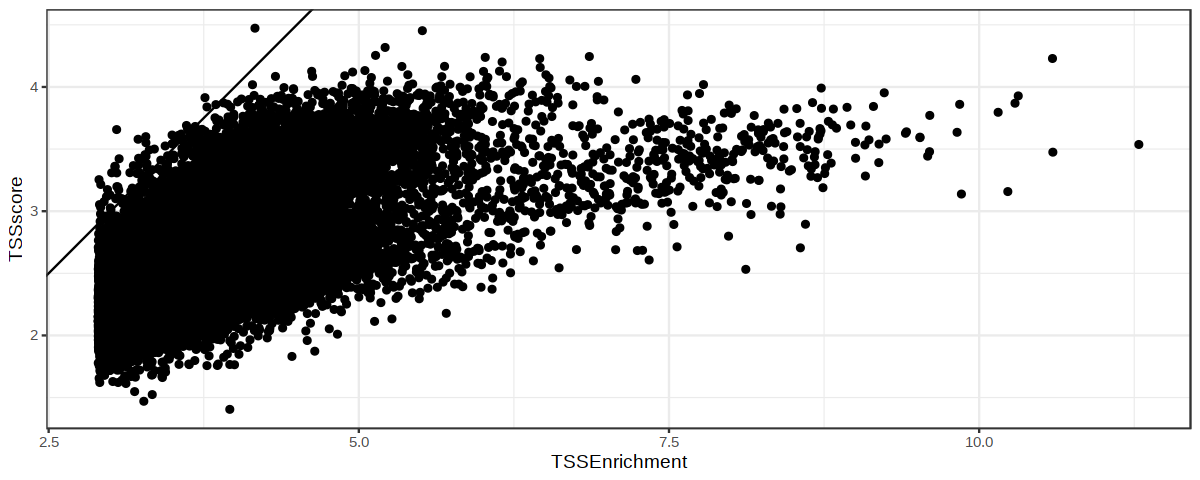

In [7]:
options(repr.plot.width=10, repr.plot.height=4)
ggplot(meta, aes(TSSEnrichment, TSSscore)) + geom_point() + geom_abline(slope=1) + theme_bw()

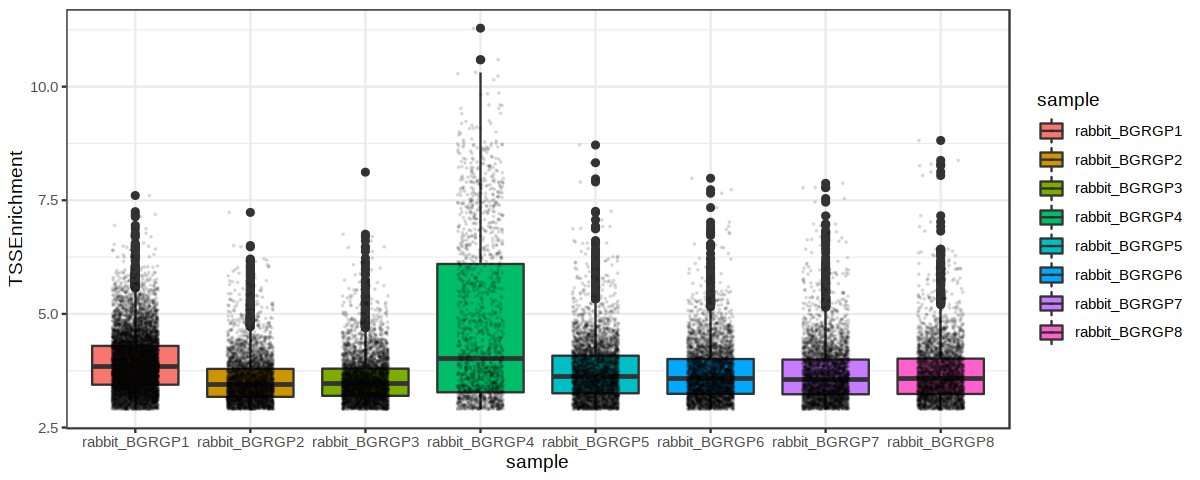

In [8]:
ggplot(meta, aes(sample, TSSEnrichment, fill=sample)) + geom_boxplot(alpha=1) + geom_point(position=position_jitter(width=0.2), size=0.05, alpha=0.1)  + theme_bw()

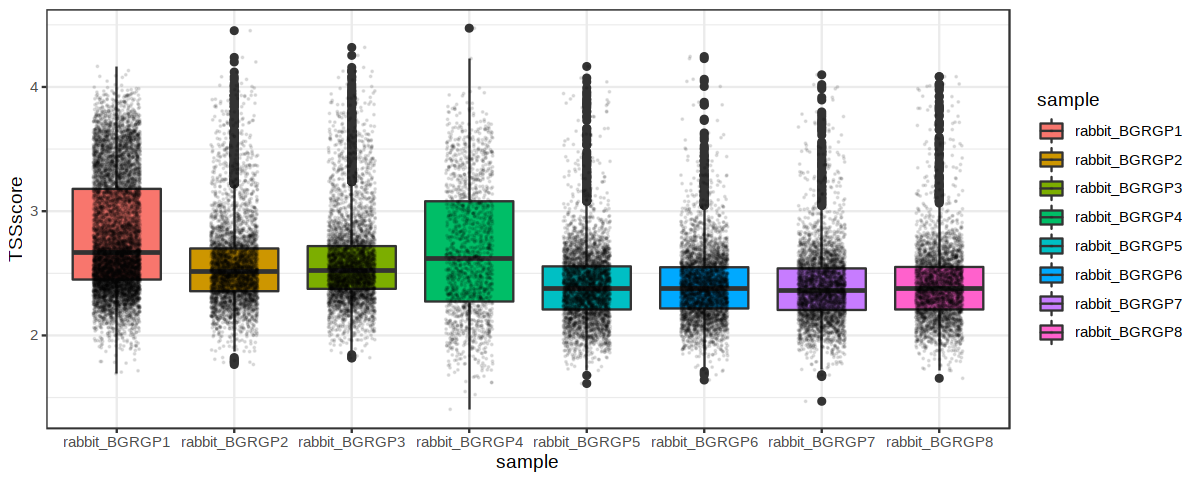

In [9]:
ggplot(meta, aes(sample, TSSscore, fill=sample)) + geom_boxplot(alpha=1) + geom_point(position=position_jitter(width=0.2), size=0.05, alpha=0.1)  + theme_bw()

# FRIP in high quality peaks


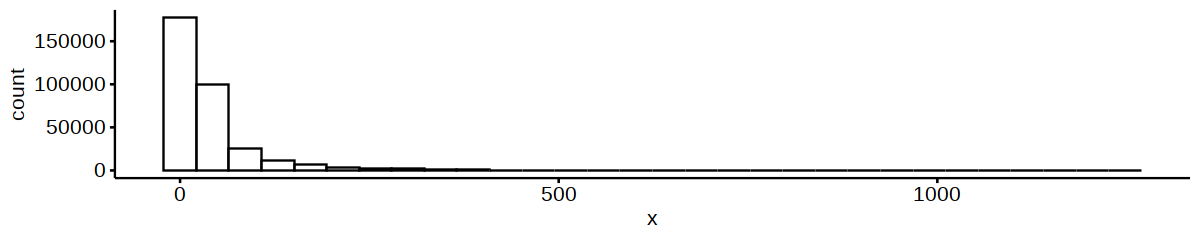

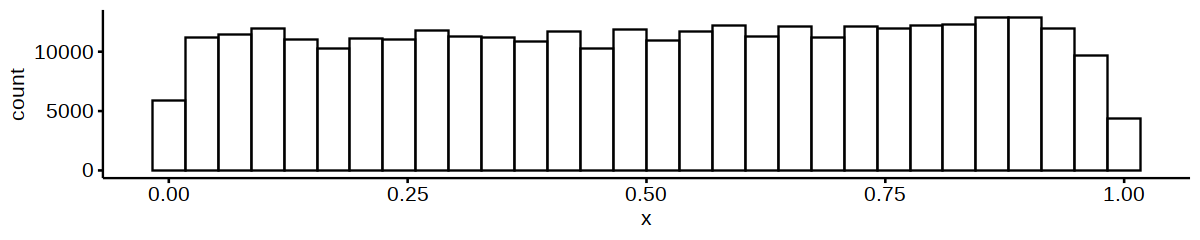

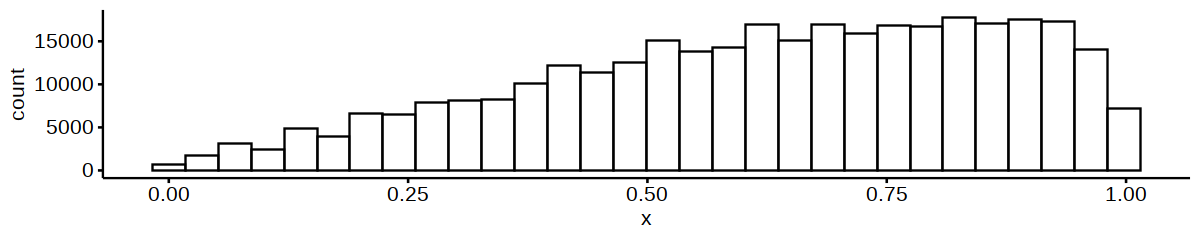

In [25]:
options(repr.plot.width=10, repr.plot.height=2)
gghistogram(ArchRProject@peakSet$score, bins=30)
gghistogram(ArchRProject@peakSet$groupScoreQuantile, bins=30)
gghistogram(ArchRProject@peakSet$replicateScoreQuantile, bins=30)

In [29]:
ArchRProject@peakSet[ArchRProject@peakSet$replicateScoreQuantile >0.5 & 
                    # ArchRProject@peakSet$groupScoreQuantile > 0.5 &
                     ArchRProject@peakSet$score >35 ]

GRanges object with 102092 ranges and 13 metadata columns:
      seqnames              ranges strand |     score replicateScoreQuantile
         <Rle>           <IRanges>  <Rle> | <numeric>              <numeric>
   C5     chr1             131-631      * |   65.4363                  0.861
   C5     chr1            995-1495      * |  118.1800                  0.921
   C5     chr1           1710-2210      * |  251.2080                  0.975
  C12     chr1           2678-3178      * |   44.1063                  0.881
   C5     chr1           4724-5224      * |   44.4458                  0.804
  ...      ...                 ...    ... .       ...                    ...
  C16     chrX 111496966-111497466      * |   43.8990                  0.796
  C15     chrX 111523289-111523789      * |  162.2790                  0.958
  C20     chrX 111524121-111524621      * |   36.5940                  0.858
  C16     chrX 111630125-111630625      * |   53.1107                  0.829
  C15     chrX 11

In [6]:
library(stringr)

In [30]:
calculate_FRIP = function(Arrow, name){
    tmp = addFeatureMatrix(Arrow, 
                 features = ArchRProject@peakSet[ArchRProject@peakSet$replicateScoreQuantile >0.5 & ArchRProject@peakSet$score >35 ],
                 matrixName = name)
    
    tmp2 = as.data.table(tmp, keep.rownames=T) %>% 
         setnames('rn', 'input') %>%
        .[input!='ArrowFile'] %>% 
         .[,`:=`(stat=str_split(input, '\\.') %>% map_chr(1),
                cell=str_split(input, '\\.') %>% map_chr(2))] %>%
        .[stat=='FRIP'] %>%
        .[,c('cell', 'tmp')] %>% setnames('tmp', paste0('FRIP_', name))
    
    return(tmp2)
}

In [31]:
FRIP_genes = mclapply(ArchRProject@sampleColData$ArrowFiles, calculate_FRIP, name='high_Q_peaks', mc.cores=16) %>%
    rbindlist() %>% .[,FRIP_high_Q_peaks:=as.numeric(FRIP_high_Q_peaks)]

In [32]:
fwrite(FRIP_genes, sprintf('%s/high_Q_peaks_FRIP.txt.gz', io$outdir))

In [33]:
test = FRIP_genes[,sample:=str_split(cell, '#') %>% map_chr(1)] %>% .[,FRIP_Gene:=as.numeric(FRIP_high_Q_peaks)]

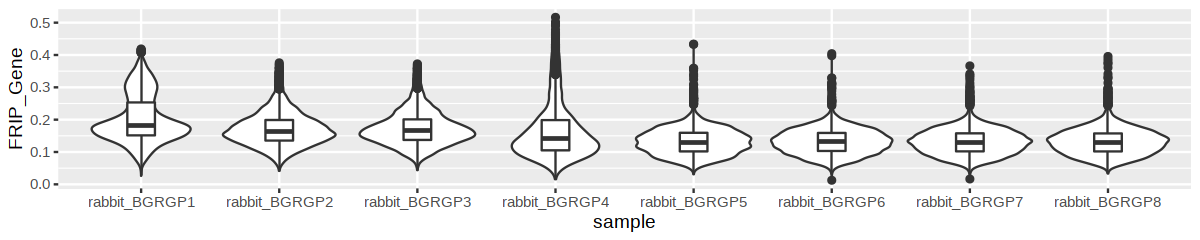

In [34]:
ggplot(test, aes(sample, FRIP_Gene)) + geom_violin() + geom_boxplot(width=0.2)

In [35]:
meta = as.data.frame(ArchRProject@cellColData)

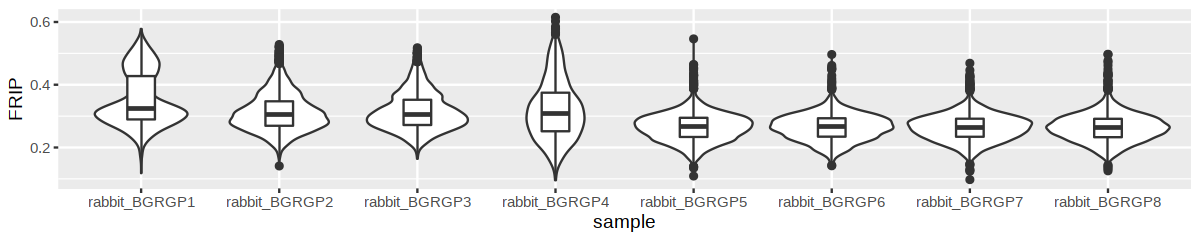

In [36]:
ggplot(meta, aes(sample, FRIP)) + geom_violin() + geom_boxplot(width=0.2)

# FRIP recalculate with peakset

In [7]:
calculate_FRIP = function(Arrow, name){
    tmp = addFeatureMatrix(Arrow, 
                 features = ArchRProject@peakSet,
                 matrixName = "Peakset_test")
    
    tmp2 = as.data.table(tmp, keep.rownames=T) %>% 
         setnames('rn', 'input') %>%
        .[input!='ArrowFile'] %>% 
         .[,`:=`(stat=str_split(input, '\\.') %>% map_chr(1),
                cell=str_split(input, '\\.') %>% map_chr(2))] %>%
        .[stat=='FRIP'] %>%
        .[,c('cell', 'tmp')] %>% setnames('tmp', paste0('FRIP_', name))
    
    return(tmp2)
}

In [8]:
test = calculate_FRIP(ArchRProject@sampleColData$ArrowFiles[4], 'Peaks_test')

In [9]:
FRIP_Peaks = lapply(ArchRProject@sampleColData$ArrowFiles, calculate_FRIP, name='Peaks_test') %>%
    rbindlist() %>% .[,FRIP_Peaks_test:=as.numeric(FRIP_Peaks_test)]

In [10]:
fwrite(FRIP_Peaks, sprintf('%s/Peaks_test_FRIP.txt.gz', io$outdir))

In [11]:
FRIP_genes = fread(sprintf('%s/Peaks_test_FRIP.txt.gz', io$outdir))

In [12]:
round(median(FRIP_genes$FRIP_Peaks_test),2)

[1] 0.27

In [13]:
meta = as.data.table(ArchRProject@cellColData)

In [14]:
test = FRIP_genes[,sample:=str_split(cell, '#') %>% map_chr(1)] %>% 
    .[,FRIP_Gene:=as.numeric(FRIP_Peaks_test)] %>%
    merge(., meta[,c('sample', 'stage')] %>% unique(by='sample'), by='sample') %>%
    .[,sample:=gsub('rabbit_', '', sample)]

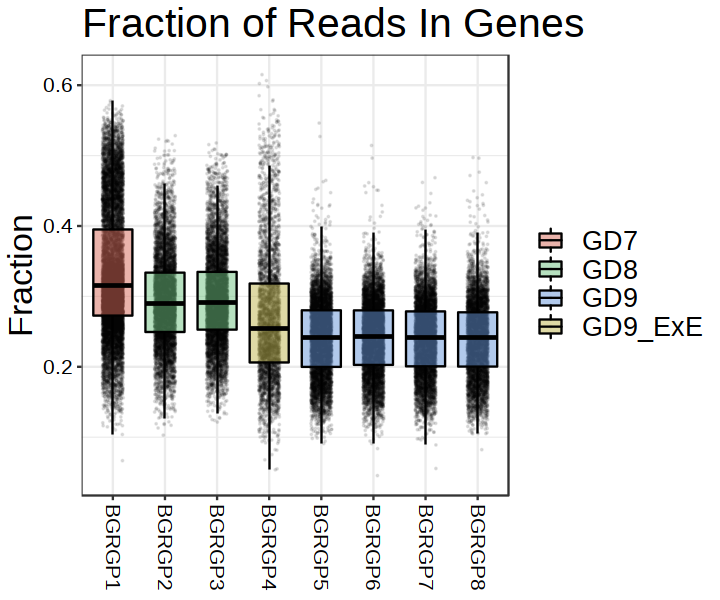

In [24]:
options(repr.plot.width=6, repr.plot.height=5)
p = ggplot(test, aes(sample, FRIP_Gene, fill=stage)) + 
  #  geom_violin() + 
    geom_point(size=0.05, alpha=0.1, position=position_jitter(width = 0.2)) + 
    geom_boxplot(outlier.shape=NA, alpha=0.5, col='black') +
    scale_fill_manual(values=opts$stage.colors) + 
    ggtitle('Fraction of Reads In Genes') + 
    ylab('Fraction') + 
    theme_bw() +
    theme(
            legend.position = "right",
            legend.title = element_blank(),
            axis.text.x = element_text(colour="black",size=rel(0.75), angle=-90, hjust=0, vjust=0.5),  
            axis.text.y = element_text(colour="black",size=rel(0.75)),  
            axis.title.x = element_blank(),
            text=element_text(size=20, colour='black'),
            strip.background=element_blank()
        ) 
p

In [34]:
median(test$FRIP_Gene)

[1] 0.2702033

In [35]:
median(meta$FRIP)

[1] 0.2888149

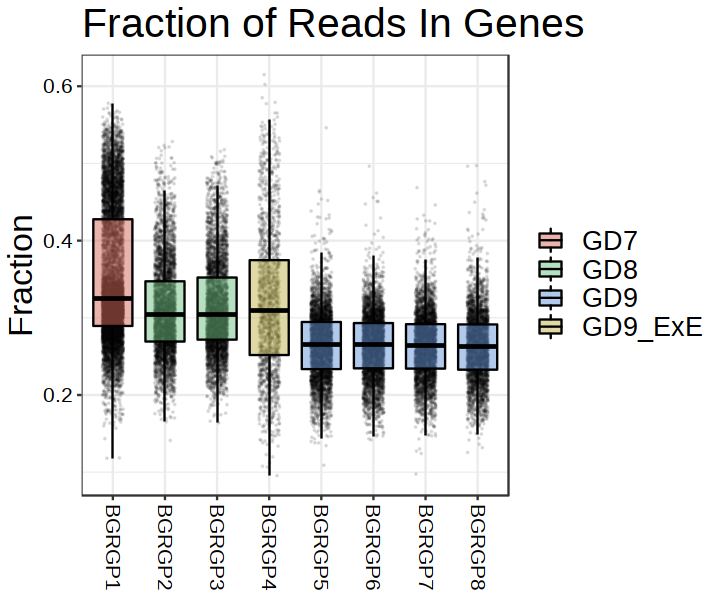

In [32]:
options(repr.plot.width=6, repr.plot.height=5)
p = ggplot(test[cell%in%meta$cell], aes(sample, FRIP_Gene, fill=stage)) + 
  #  geom_violin() + 
    geom_point(size=0.05, alpha=0.1, position=position_jitter(width = 0.2)) + 
    geom_boxplot(outlier.shape=NA, alpha=0.5, col='black') +
    scale_fill_manual(values=opts$stage.colors) + 
    ggtitle('Fraction of Reads In Genes') + 
    ylab('Fraction') + 
    theme_bw() +
    theme(
            legend.position = "right",
            legend.title = element_blank(),
            axis.text.x = element_text(colour="black",size=rel(0.75), angle=-90, hjust=0, vjust=0.5),  
            axis.text.y = element_text(colour="black",size=rel(0.75)),  
            axis.title.x = element_blank(),
            text=element_text(size=20, colour='black'),
            strip.background=element_blank()
        ) 
p

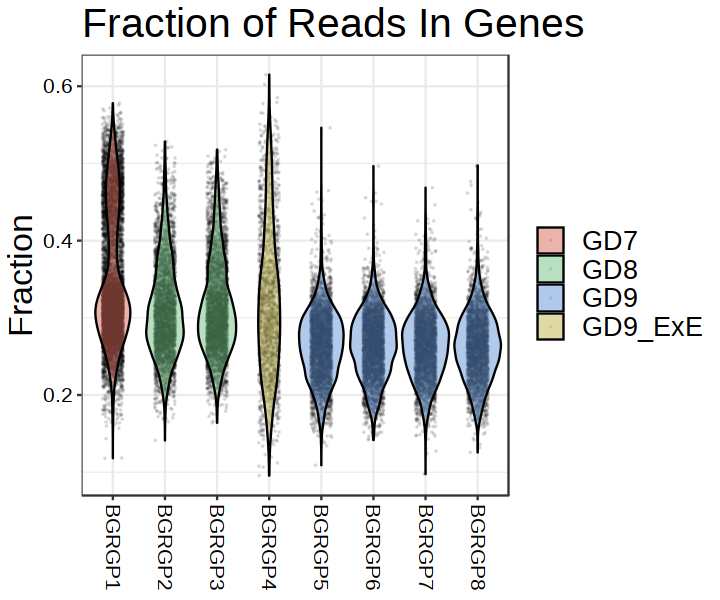

In [27]:
options(repr.plot.width=6, repr.plot.height=5)
p = ggplot(meta[,sample:=gsub('rabbit_', '', sample)], aes(sample, FRIP, fill=stage)) + 
  #  geom_violin() + 
    geom_point(size=0.05, alpha=0.1, position=position_jitter(width = 0.2)) + 
    geom_boxplot(outlier.shape=NA, alpha=0.5, col='black') +
    scale_fill_manual(values=opts$stage.colors) + 
    ggtitle('Fraction of Reads In Genes') + 
    ylab('Fraction') + 
    theme_bw() +
    theme(
            legend.position = "right",
            legend.title = element_blank(),
            axis.text.x = element_text(colour="black",size=rel(0.75), angle=-90, hjust=0, vjust=0.5),  
            axis.text.y = element_text(colour="black",size=rel(0.75)),  
            axis.title.x = element_blank(),
            text=element_text(size=20, colour='black'),
            strip.background=element_blank()
        ) 
p

In [46]:
meta[,N:=.N, by='predictedGroup_celltype_PeakMatrix'] %>% .[N<25, predictedGroup_celltype_PeakMatrix]  %>% unique()

[1] "Notochord"                 "PGC"                      
 [3] "Cranial mesoderm"          "Cardiomyocytes FHF 1"     
 [5] "MEP"                       "Migratory neural crest"   
 [7] "Nephron progenitors"       "Non-neural ectoderm 2"    
 [9] "Posterior somitic tissues" "Placodal ectoderm"        
[11] "Non-neural ectoderm 4"     "Gut tube"

In [48]:
table(meta$predictedGroup_celltype_PeakMatrix)


                      Allantois           Allantois endothelium 
                            822                              43 
                       Amnion 1                        Amnion 2 
                            403                             223 
      Anterior Primitive Streak            Cardiomyocytes FHF 1 
                             25                               8 
           Cardiomyocytes FHF 2    Cardiopharyngeal progenitors 
                           1219                              82 
                Caudal mesoderm                Cranial mesoderm 
                            964                              11 
           Cranial neural crest                 Cytotrophoblast 
                            613                            1137 
            Definitive Endoderm                    Dermomyotome 
                            404                            1677 
        Differentiating neurons       Embryo proper endothelium 
                        

In [50]:
meta[,N:=.N, by='predictedGroup_celltype_PeakMatrix'][,c('predictedGroup_celltype_PeakMatrix', 'N')]%>% unique(by='predictedGroup_celltype_PeakMatrix') %>% .[order(-N)]

predictedGroup_celltype_PeakMatrix,N
<chr>,<int>
Epiblast,3675
Hypoblast,3248
Hindbrain,3084
Forebrain,1751
Dermomyotome,1677
Midbrain,1418
Lateral plate mesoderm,1349
Cardiomyocytes FHF 2,1219
Cytotrophoblast,1137


In [47]:
nrow(meta[FRIP<0.15])

[1] 57